This is firs assignment (out of three). 

Submission guideline:

- Total point- 100 

- Attend all questions.

- Upload a zip/rar file containing the following:

    - MAS512_assignment1_gr#.py or MAS512_assignment1_gr#.ipynb. These files should be error free.

    - Each questions should be done in a cell, such that when I run the cell - I get the outputs.
    
    - MAS512_assignment1_gr#.ppt explaining the objective, method and results of each questions. 
    
    - Make   the presentation clear, readable, precise and attractive.

- Each group will be given 10 min to present the assignment followed by 5 minutes of Q/A. The presentation takes place in Lab, and all students are expected to attend peer's presentation

- Assignment is graded based on problem solving skills, work break down, algorithms, code, powerpoint and presentation

- Students are expected to solve the problem themselves.

- You can use LLM generative models as 'help', understand the working and algorithm, modify and use them.

- Be specific and precise when you write code, make powerpoint and present assignment

# Q1. Object detection and depth estimation                             20+5+20 = 45 points
 Use L515 camera in Lab to acquire rgb video and depth video (e.g. 30 s) of swinging load in lab (rgb_train_val_swingingload.avi; depth_train_val_swingingload.avi). Extract each frames from rgb video. Use the extracted images to train and validate YOLO model (save as YOLO_swinging_load.pt). Record test_swingingload.avi (e.g. 5 s). Extract frames and use them as test data set. Test your YOLO model (YOLO_swinging_load.pt) on this test data set.

(a) Show the performance of your model on test data set by plotting relevant KPIs.

(b) Sample five random images from test data video (test_swingingload.avi). Find the center, and coordinates of bounding box. Display them on the each test image.

(c) realsense_acq.ipynb contains code that streams, rgb, and depth video. Based on this code, extract the frames from depth_train_val_swingingload.avi. Each pixel in each frame consists of depth information of corresponding rgb images. As described in Q1.b find the center of bounding box of ALL frames in  test video (test_swingingload.avi). Display its center and corresponding depth.


References: Use Ultralytics framework for help - https://docs.ultralytics.com/tasks/detect
Realsense - https://dev.realsenseai.com/sdk-2-0-code-samples-wrappers-and-languages/opencv/ 

# Q2. Object tracking                                                           5 points
  Perform tracking of swinging load on test_swingingload.avi. You should display the trajectory of load as it swings each frame as shown in Fig. below. 

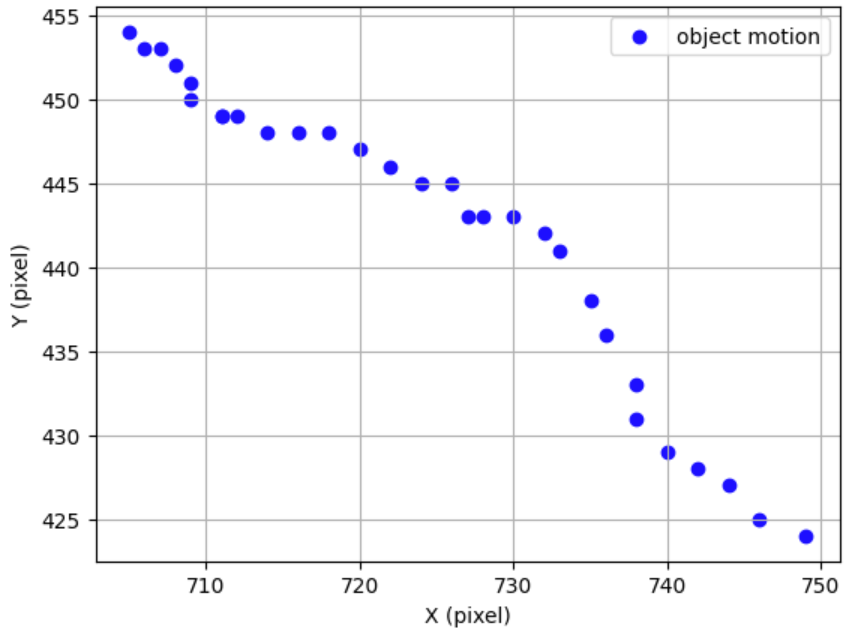

Ref: Use help from Ultralytics - https://docs.ultralytics.com/guides/instance-segmentation-and-tracking 

# Q3. Multi object segmentation, tracking and counting:                         10  points

Explore different data-set available freely on internet (https://docs.ultralytics.com/datasets ). Get familiar with them. Then choose a data set and corresponding class of your choice (e.g. CICAR-10 dataset/COCO data set or KITTI data set / person). Then make a video such that multiple instances of objects are in the scene (e.g. 5 people are the scene). Perform 
(a) instance segmentation, 
(b) counting  - total number of object in scene
(c) and tracking of individual instance of object
(d) draw a region - and count the object in that region


# Q4. Classification                                                        10  marks
Given the data-set fault-classification-class. Perform the following
(a) Develop ML model to determine the state of health of asset (in this case motor).
(b) Show, train and val loss, confusion matrix and classification report
(c) Consider the one in the class as baseline and compare your model with it. Summarize in terms of
model parameter, inference time, accuracy, precision, recall, F1 score

# Q5. Classification                                                        20  
Download CFAR-10 dataset (https://www.tensorflow.org/datasets/catalog/cifar10). Perform the classification task on this dataset 
(a) Use model fusion (use two or models to extract feature and combine them), 
(b) Use transfer learning
(c) Use finetuning
(d) Compare different methods (a) - (c) in terms of typical KPIs often used for classification

# Q6. Autoencoder                                                           10 marks
Given the data-set fault-classification-class, 
Use Auto encoder to compress the data to latent space and reconstruct it back. Show the following for random 10 iamges from each class
(a) Original image
(b) Latent vector
(c) Reconstructed back image
(d) individual reconstruction error and mean loss for each class.


Q1
Detection - Find the object in scene
3D - RGB image

1. Film rgb_train_val_swingingload.avi

2. trekk ut frames: Open CV
https://dev.realsenseai.com/sdk-2-0-code-samples-wrappers-and-languages/opencv/
https://opencv.org/reading-and-writing-videos-using-opencv/#h-import-cv2

3. annoter lasten
4. tren egen YOLO-modell
5. lagre modellen som YOLO_swinging_load.pt
6. kjør den på test_swingingload.avi

In [ ]:

#First we have to extraxt frames from video to be able to later use them for training.
#2 # 1. Extract frames from the training RGB video
Source: OpenCV-Python Tutorials -> "Getting Started with Videos"

#OPENCV to process video (Source: https://docs.opencv.org/4.x/dd/d43/tutorial_py_video_display.html)
import cv2

#open videofile
cap = cv2.VideoCapture('rgb_train_val_swingingload.avi')


#to be able to save each picture with a unique name, using a counter. Instead of only looking at last picture.
frame_count = 0

#Makes sure the code goes through every frame in the video.
while(cap.isOpened()):
    ret, frame = cap.read()

    if ret == True:
        cv2.imwrite('frame_' + str(frame_count) + '.jpg', frame)
        frame_count += 1
    else:
        break

#Close the video file
cap.release()





#2 trekk ut frames

#3 Annoter lasten

#4 Tren egen YOLO modell

In [ ]:
#TRAIN

from ultralytics import YOLO

# Load a model
model = YOLO("yolo26n.yaml")  # build a new model from YAML
model = YOLO("yolo26n.pt")  # load a pretrained model (recommended for training)
model = YOLO("yolo26n.yaml").load("yolo26n.pt")  # build from YAML and transfer weights

# Train the model
results = model.train(data="coco8.yaml", epochs=100, imgsz=640)